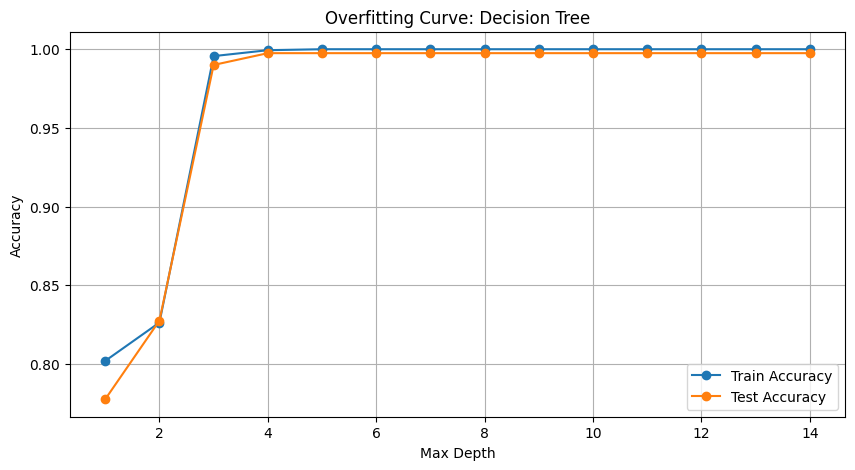

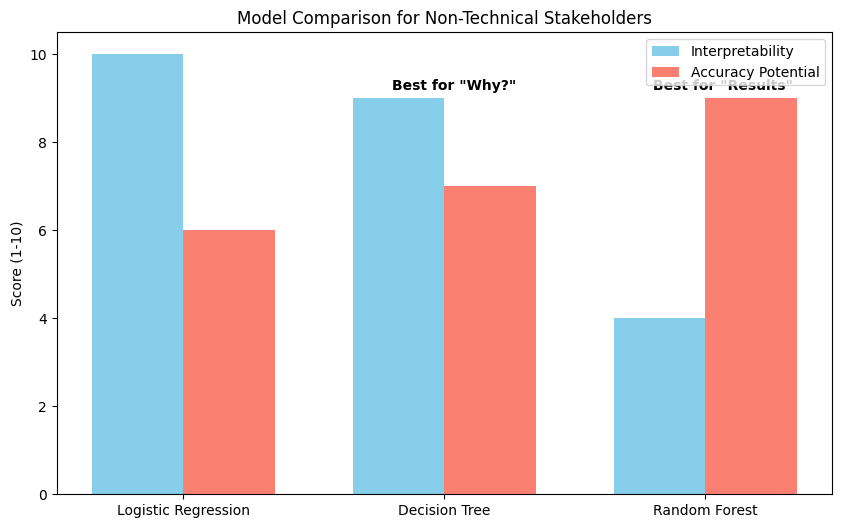

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance


np.random.seed(42)
n_samples = 2000

data = {
    'annual_income': np.random.randint(30000, 150000, n_samples),
    'credit_score': np.random.randint(500, 850, n_samples),
    'loan_amount': np.random.randint(5000, 50000, n_samples),
    'employment_years': np.random.randint(0, 20, n_samples),
    'debt_to_income': np.random.uniform(0.1, 0.6, n_samples),
    'num_credit_cards': np.random.randint(1, 10, n_samples)
}

df = pd.DataFrame(data)
df['approved'] = ((df['credit_score'] > 680) & (df['debt_to_income'] < 0.4) |
                 (df['annual_income'] > 100000) & (df['credit_score'] > 600)).astype(int)

X = df.drop('approved', axis=1)
y = df['approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_grid, cv=5, n_iter=5)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_


def plot_overfitting_curve(X, y, max_depths):
    train_acc, test_acc = [], []
    X_t, X_v, y_t, y_v = train_test_split(X, y, test_size=0.2, random_state=42)

    for d in max_depths:
        clf = DecisionTreeClassifier(max_depth=d, random_state=42)
        clf.fit(X_t, y_t)
        train_acc.append(clf.score(X_t, y_t))
        test_acc.append(clf.score(X_v, y_v))

    plt.figure(figsize=(10, 5))
    plt.plot(max_depths, train_acc, label='Train Accuracy', marker='o')
    plt.plot(max_depths, test_acc, label='Test Accuracy', marker='o')
    plt.xlabel('Max Depth')
    plt.ylabel('Accuracy')
    plt.title('Overfitting Curve: Decision Tree')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_overfitting_curve(X, y, range(1, 15))


def plot_comparison_infographic():
    models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
    interpretability = [10, 9, 4]
    accuracy = [6, 7, 9]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, interpretability, width, label='Interpretability', color='skyblue')
    ax.bar(x + width/2, accuracy, width, label='Accuracy Potential', color='salmon')

    ax.set_ylabel('Score (1-10)')
    ax.set_title('Model Comparison for Non-Technical Stakeholders')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    plt.annotate('Best for "Why?"', xy=(0.8, 9.2), weight='bold')
    plt.annotate('Best for "Results"', xy=(1.8, 9.2), weight='bold')
    plt.show()

plot_comparison_infographic()
